In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load and Understand the Data

In [3]:
# Loading events.csv file

df = pd.read_csv('../data/raw/events.csv')

In [4]:
df.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [5]:
df.shape

(2756101, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


In [8]:
# Check unique values in event column

df['event'].value_counts()

event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64

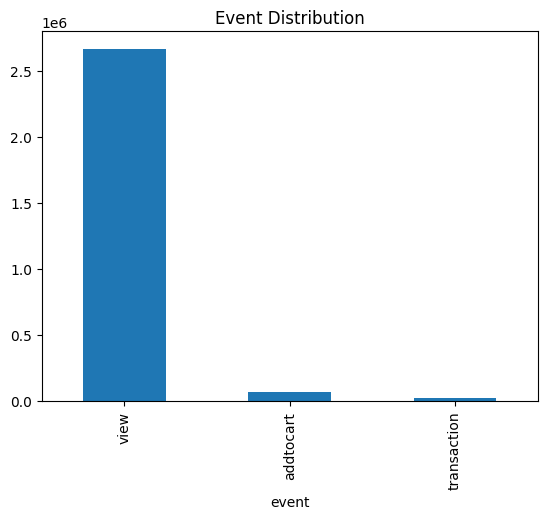

In [11]:
# Destribution of the Event column

df['event'].value_counts().plot(kind='bar')
plt.title("Event Distribution")
plt.show()

In [ ]:
# Check is there any non-unique users

df['visitorid'].nunique()

1407580

In [12]:
# top active users

df['visitorid'].value_counts().head()

visitorid
1150086    7757
530559     4328
152963     3024
895999     2474
163561     2410
Name: count, dtype: int64

In [10]:
# missing values

df.isnull().sum()

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

In [13]:
df.describe(include='all')


,timestamp,visitorid,event,itemid,transactionid
count,2.756101e+06,2.756101e+06,2756101,2.756101e+06,22457.000000
unique,NaN,NaN,3,NaN,NaN
top,NaN,NaN,view,NaN,NaN
freq,NaN,NaN,2664312,NaN,NaN
mean,1.436424e+12,7.019229e+05,NaN,2.349225e+05,8826.497796
std,3.366312e+09,4.056875e+05,NaN,1.341954e+05,5098.996290
min,1.430622e+12,0.000000e+00,NaN,3.000000e+00,0.000000
25%,1.433478e+12,3.505660e+05,NaN,1.181200e+05,4411.000000
50%,1.436453e+12,7.020600e+05,NaN,2.360670e+05,8813.000000
75%,1.439225e+12,1.053437e+06,NaN,3.507150e+05,13224.000000


Observation:
- Dataset contains user interaction logs from an e-commerce platform
- Most events are "view" actions
- Only a small portion leads to "transactions"
- Dataset is highly imbalanced
- Timestamp is in Unix format and needs conversion

## Data Cleaning

In [14]:
# convert timestamp

df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')

In [15]:
df[['datetime', 'timestamp']].head()

,datetime,timestamp
0,2015-06-02 05:02:12.117,1433221332117
1,2015-06-02 05:50:14.164,1433224214164
2,2015-06-02 05:13:19.827,1433221999827
3,2015-06-02 05:12:35.914,1433221955914
4,2015-06-02 05:02:17.106,1433221337106


In [16]:
# Remove Duplicates

df = df.drop_duplicates()

In [17]:
df.shape

(2755641, 6)

In [19]:
# Handle missing values

df.isnull().sum()

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733184
datetime               0
dtype: int64

In [20]:
df = df.dropna(subset=['visitorid', 'itemid', 'event'])

In [21]:
# Sort data

df = df.sort_values(by=['visitorid', 'datetime'])

In [23]:
df['event'].value_counts()

event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64

In [24]:
df['visitorid'].nunique()

1407580

## Merge Dataset

In [25]:
category = pd.read_csv("../data/raw/category_tree.csv")

In [26]:
category.head()

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [27]:
# Load item properties

part_1 = pd.read_csv("../data/raw/item_properties_part1.csv")
part_2 = pd.read_csv("../data/raw/item_properties_part2.csv")

item_props = pd.concat([part_1, part_2])

# keep only categoryID
item_props = item_props[item_props['property'] == 'categoryid']

item_props = item_props[['itemid', 'value']].rename(columns={'value':'categoryid'})

# Merge with events_df

df = df.merge(item_props, on='itemid', how='left')

In [28]:
# save clean dataset

df.to_csv("../data/processed/clean_events.csv", index=False)